In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

17030
17030


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: mondial


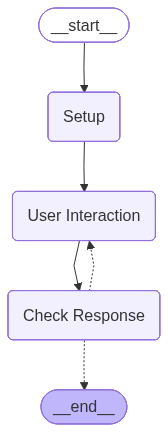

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    # Invoca a avaliação com as configurações estendidas
    eval_result = eval_graph.invoke({
        "experiment": experiment,
        "max_retries": 2,
        "debug_mode": True,
        "model_version": model_version,
        "experiment_type": experiment_type
    })

    print("Experimento avaliado:\n", eval_result["experiment_eval"])

    # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
    evals.append({
        "experiment_id": exp_id,
        "experiment_config": eval_result.get("experiment_config", {
            "max_retries": 2,
            "model_version": model_version,
            "timestamp": datetime.now().isoformat(),
            "experiment_type": experiment_type
        }),
        "experiment_eval": eval_result["experiment_eval"]
    })

    # Atualiza o arquivo salvando o resultado atual
    with open(evals_filename, 'w', encoding='utf-8') as f:
        json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  What are the latitude and longitude of airports in the database?
Decomposition
['What are the latitude and longitude of airports in the database?', 'Qual é a latitude de cada aeroporto no banco de dados?', 'Qual é a longitude de cada aeroporto no banco de dados?']
(17030,)
(17030,)
(17030,)
DFE
Question: What are the locations in terms of north-south position of the airports in the database?
SELECT IATACODE, LATITUDE FROM MONDIAL_AIRPORT

Question: What are the latitude values of the airports in the MONDIAL_AIRPORT table?
SELECT IATACODE, LATITUDE FROM MONDIAL_AIRPORT

Question: What are the latitude values stored in the MONDIAL_AIRPORT table?
SELECT IATACODE, LATITUDE FROM MONDIAL_AIRPORT

Question: What are the east-west location values of the airports in the database?
SELECT IATACODE, LONGITUDE FROM MONDIAL_AIR

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "What are the latitude and longitude of airports in the database?",
    "schema_linking": ["airport"],
    "answer": "The database contains latitude and longitude information for 1,318 airports. Examples include:\n- CNF: Latitude -19.633750, Longitude -43.968856\n- SLZ: Latitude -2.585361, Longitude -44.234139\n- CPQ: Latitude -22.859200, Longitude -47.108200\n- VCP: Latitude -23.007500, Longitude -47.134444\n- AJU: Latitude -10.984000, Longitude -37.070333",
    "sql": "SELECT IATACODE, LATITUDE, LONGITUDE FROM MONDIAL_GPT.AIRPORT"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What are the latitude and longitude of airports in the database?",
    "schema_linking": ["airport"],
    "answer": "The database contains latitude and longitude information for 1,318 airports. Examples include:\n- CNF: Latitude -19.633750, Longitude -43.968856\n- SLZ: Latitud

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


True cols: Index(['LATITUDE', 'LONGITUDE'], dtype='object')
Adj. True cols: Index(['LATITUDE', 'LONGITUDE'], dtype='object')
Predicted cols: Index(['IATACODE', 'LATITUDE', 'LONGITUDE'], dtype='object')
Adj. Predicted cols: Index(['LATITUDE', 'LONGITUDE'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Retrieve the latitude and longitude of all airports.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'What are the latitude and longitude of airports in the database?', 'agent_reply': 'The database contains latitude and longitude information for 1,318 airports. Examples include:\n- CNF: Latitude -19.633750, Longitude -43.968856\n- SLZ: Latitude -2.585361, Longitude -44.234139\n- CPQ: Latitude -22.859200, Longitude -47.108200\n- VCP: Latitude -23.007500, Longitude -47.134444\n- AJU: Latitude -10.984000, Longitude -37.070333', 'evaluation': {'text_to_sql_input': 'What are the latitude and longitude of a

...

Decomposition
['List the provinces associated with estuaries and their corresponding rivers.', 'Quais são as províncias associadas aos estuários?', 'Quais são os rios correspondentes aos estuários?']
(17030,)
(17030,)
(17030,)
DFE
Question: Which regions are associated with the countries 'Canada' and 'Russia' in the table that contains information about provinces and estuaries?
SELECT DISTINCT MP.NAME
FROM MONDIAL_PROVINCE MP
JOIN MONDIAL_GEO_ESTUARY MGE ON MP.NAME = MGE.PROVINCE
WHERE MGE.COUNTRY IN ('CDN', 'RA')

Question: What is the largest area among provinces where rivers have an estuary?
SELECT MAX(MONDIAL_PROVINCE.AREA)
FROM MONDIAL_PROVINCE
JOIN MONDIAL_GEO_ESTUARY ON MONDIAL_PROVINCE.NAME = MONDIAL_GEO_ESTUARY.PROVINCE
JOIN MONDIAL_RIVER ON MONDIAL_GEO_ESTUARY.RIVER = MONDIAL_RIVER.NAME
WHERE MONDIAL_RIVER.ESTUARY IS NOT NULL

Question: What are the estuaries in MONDIAL_GEO_ESTUARY that are associated with the countries 'GB' and 'CZ' and are located in provinces with names 'P

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "List the provinces associated with estuaries and their corresponding rivers.",
    "schema_linking": ["mondial_geo_estuary"],
    "answer": "There are 511 provinces associated with estuaries. Here are some examples: Amazonas with the Japura River, Andhra Pradesh with the Krishna River, Aquitaine with the Garonne River, Arkhangel´skaya with the Petschora River, and Astrakhanskaya with the Volga River.",
    "sql": "SELECT DISTINCT geo_estuary.province, geo_estuary.river FROM mondial_gpt.geo_estuary"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "List the provinces associated with estuaries and their corresponding rivers.",
    "schema_linking": ["mondial_geo_estuary"],
    "answer": "There are 511 provinces associated with estuaries. Here are some examples: Amazonas with the Japura River, Andhra Pradesh with the Krishna River, Aquitaine with the Garon

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


Decomposition
['Provide details about the sources of the rivers that flow through estuaries, including their countries and provinces.']
(17030,)
DFE
Question: Which information can be found in the database about estuaries where the countries are South Sudan and Democratic Republic of the Congo, and the river is the Danube?
SELECT RIVER, COUNTRY
FROM MONDIAL_GEO_ESTUARY
WHERE (COUNTRY = 'SSD' OR COUNTRY = 'ZRE') AND LOWER(RIVER) = LOWER('Donau')

Question: What are the sources of rivers in the table MONDIAL_RIVER that have estuaries in countries with the country codes 'SRB' or 'ROK' in the table MONDIAL_GEO_ESTUARY?
SELECT MONDIAL_RIVER.NAME, MONDIAL_RIVER.SOURCE
FROM MONDIAL_RIVER
JOIN MONDIAL_GEO_ESTUARY ON MONDIAL_RIVER.NAME = MONDIAL_GEO_ESTUARY.RIVER
WHERE MONDIAL_GEO_ESTUARY.COUNTRY IN ('SRB', 'ROK')

Question: Which information can be found in the database about estuaries where the countries are 'United Kingdom' and 'Mexico' and the rivers are 'Sava' and 'Tiber'?
SELECT RIVER, CO